# L=32 frozen ResNet-18 — matched all-bin wide-grid analysis

## Matched data and analysis design

Every saved configuration is one observation. All ten bins for all 10,000 seeds and all 41 temperatures are included independently: **4.1 million observations per representation**. PCA and K-means are fitted on the same balanced 410,000 observation subset, then evaluated on every configuration. No spin inversion, temperature label, supervised classifier, or configuration averaging is used.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_SITES = L ** 2
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE
TEMPERATURES = np.array([2.133034, 2.155726, 2.178418, 2.201110, 2.223802, 2.235148, 2.240820, 2.246493, 2.252166, 2.257839, 2.263512, 2.269185, 2.274858, 2.280531, 2.286204, 2.291877, 2.297550, 2.303223, 2.308896, 2.314569, 2.320242, 2.325915, 2.331588, 2.337261, 2.342934, 2.348607, 2.354280, 2.359953, 2.365626, 2.371299, 2.376972, 2.382645, 2.388318, 2.393991, 2.416682, 2.439374, 2.462066, 2.484758, 2.507450, 2.530142, 2.541488], dtype=np.float64)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw" / "ising32_wide_dense").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw" / "ising32_wide_dense"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed" / "ising32_wide_dense" / "matched_all_bins"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

run_dirs = sorted(DATA_ROOT.glob("ising32_wide_dense_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(run_dirs) == N_RUNS

SPINS_PATH = OUTPUT_ROOT / "all_spin_configurations.npy"
if not SPINS_PATH.exists():
    cache = np.lib.format.open_memmap(
        SPINS_PATH, mode="w+", dtype=np.int8,
        shape=(N_CONFIGURATIONS, L, L),
    )
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        name = run_dir.name
        block = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8).reshape(-1, L, L)
        assert block.shape == (N_TEMPERATURES * BINS_PER_TEMPERATURE, L, L)
        cache[offset:offset + len(block)] = block
        offset += len(block)
        if (run_index + 1) % 500 == 0:
            print(f"Cached {run_index + 1:,}/{N_RUNS:,} runs")
    cache.flush()
    del cache

all_spins = np.load(SPINS_PATH, mmap_mode="r")
assert all_spins.shape == (N_CONFIGURATIONS, L, L)
configuration_temperatures = np.tile(np.repeat(TEMPERATURES, BINS_PER_TEMPERATURE), N_RUNS)

# The same balanced 410,000 configurations fit both PCA bases and both K-means models:
# one rotating bin for every seed-temperature pair. All 4.1 million configurations are
# subsequently transformed, assigned, and included in temperature-population curves.
run_ids = np.arange(N_RUNS)[:, None]
temperature_ids = np.arange(N_TEMPERATURES)[None, :]
fit_bins = (run_ids + temperature_ids) % BINS_PER_TEMPERATURE
FIT_INDICES = ((run_ids * N_TEMPERATURES + temperature_ids) * BINS_PER_TEMPERATURE + fit_bins).reshape(-1)
assert len(FIT_INDICES) == N_RUNS * N_TEMPERATURES

signed_magnetization = all_spins.reshape(N_CONFIGURATIONS, -1).mean(axis=1, dtype=np.float64).astype(np.float32)
print(f"{N_CONFIGURATIONS:,} matched configurations; {len(FIT_INDICES):,} balanced fit observations")
print(f"Temperature range: {TEMPERATURES[0]:.3f}–{TEMPERATURES[-1]:.3f}; device={torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Cached 500/10,000 runs


Cached 1,000/10,000 runs


Cached 1,500/10,000 runs


Cached 2,000/10,000 runs


Cached 2,500/10,000 runs


...

Cached 8,500/10,000 runs


Cached 9,000/10,000 runs


Cached 9,500/10,000 runs


Cached 10,000/10,000 runs


4,100,000 matched configurations; 410,000 balanced fit observations
Temperature range: 2.133–2.541; device=cuda


## Magnetization calculated directly from the spins

For each saved configuration, calculate the signed magnetization per site directly as

\[
m = \frac{1}{L^2}\sum_{i=1}^{L^2}s_i.
\]

The plotted order parameter is the temperature-wise mean absolute magnetization, \(\langle |m|\rangle\). Error bars are the standard error over all 100,000 configurations at each temperature (10,000 seeds × 10 saved bins).

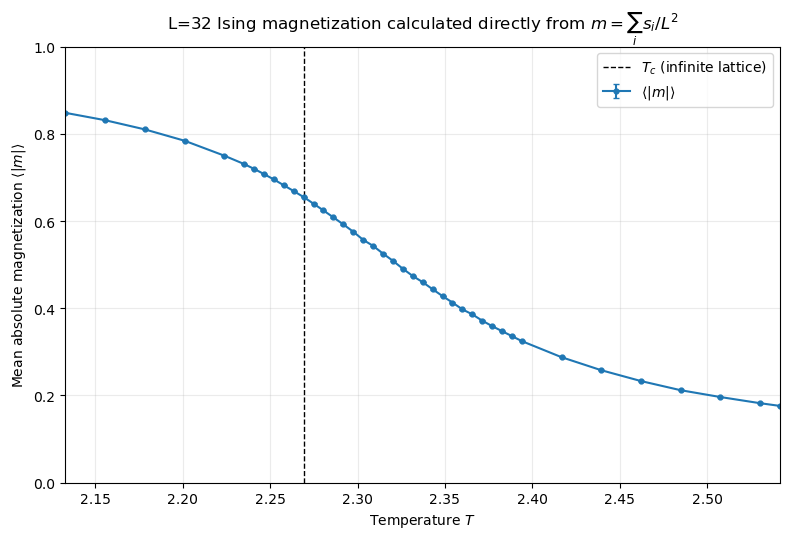

,temperature,mean_absolute_magnetization,standard_error,n_configurations
0,2.133034,0.847973,0.000175,100000
1,2.155726,0.831108,0.000208,100000
2,2.178418,0.810032,0.000250,100000
3,2.201110,0.784054,0.000307,100000
4,2.223802,0.749868,0.000386,100000
5,2.235148,0.730655,0.000422,100000
6,2.240820,0.719614,0.000442,100000
7,2.246493,0.707734,0.000468,100000
8,2.252166,0.695298,0.000490,100000
9,2.257839,0.681966,0.000515,100000


In [2]:
# signed_magnetization was calculated directly from all_spins by summing over L^2 sites.
magnetization_rows = []
for temperature in TEMPERATURES:
    values = np.abs(signed_magnetization[configuration_temperatures == temperature])
    magnetization_rows.append({
        "temperature": temperature,
        "mean_absolute_magnetization": float(values.mean()),
        "standard_error": float(values.std(ddof=1) / np.sqrt(len(values))),
        "n_configurations": int(len(values)),
    })

magnetization_table = pd.DataFrame(magnetization_rows)
magnetization_table.to_csv(
    OUTPUT_ROOT / "ising32_all_bins_absolute_magnetization.csv", index=False
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(
    magnetization_table.temperature,
    magnetization_table.mean_absolute_magnetization,
    yerr=magnetization_table.standard_error,
    fmt="o-",
    markersize=3.5,
    linewidth=1.5,
    capsize=2,
    label=r"$\langle |m| \rangle$",
)
ax.axvline(
    TC,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$T_c$ (infinite lattice)",
)
ax.set(
    xlabel="Temperature $T$",
    ylabel=r"Mean absolute magnetization $\langle |m| \rangle$",
    title=r"L=32 Ising magnetization calculated directly from $m=\sum_i s_i/L^2$",
    xlim=(TEMPERATURES.min(), TEMPERATURES.max()),
    ylim=(0, 1),
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "ising32_all_bins_absolute_magnetization.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)
magnetization_table

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fit_covariance_pca(features, cache_path, batch_size=4096):
    if cache_path.exists():
        saved = np.load(cache_path)
        return saved["mean"], saved["eigenvalues"], saved["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(FIT_INDICES), batch_size):
        indices = FIT_INDICES[start:start + batch_size]
        batch = torch.tensor(np.asarray(features[indices], dtype=np.float32), device=DEVICE, dtype=torch.float64)
        total += batch.sum(0)
        second += batch.T @ batch
    mean_t = total / len(FIT_INDICES)
    covariance = (second - len(FIT_INDICES) * torch.outer(mean_t, mean_t)) / (len(FIT_INDICES) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy()
    eigenvalues = values[order].cpu().numpy()
    components = vectors[:, order].T.cpu().numpy()
    np.savez(cache_path, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def project(features, indices, mean, components):
    return (np.asarray(features[indices], dtype=np.float32) - mean) @ components.T

def score_first_six(features, mean, components, cache_path, batch_size=8192):
    if cache_path.exists():
        return np.load(cache_path, mmap_mode="r")
    cache = np.lib.format.open_memmap(cache_path, mode="w+", dtype=np.float32, shape=(N_CONFIGURATIONS, 6))
    for start in range(0, N_CONFIGURATIONS, batch_size):
        stop = min(start + batch_size, N_CONFIGURATIONS)
        cache[start:stop] = (np.asarray(features[start:stop], dtype=np.float32) - mean) @ components[:6].T
    cache.flush(); del cache
    return np.load(cache_path, mmap_mode="r")

def overview_plot(scores6, representation_name, file_name):
    rng = np.random.default_rng(2026)
    sample = np.concatenate([
        rng.choice(np.flatnonzero(configuration_temperatures == t), size=2000, replace=False)
        for t in TEMPERATURES
    ])
    means = np.empty((N_TEMPERATURES, 6))
    errors = np.empty_like(means)
    for ti, t in enumerate(TEMPERATURES):
        values = np.asarray(scores6[configuration_temperatures == t])
        means[ti] = values.mean(0)
        errors[ti] = values.std(0, ddof=1) / np.sqrt(len(values))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
    scatter = axes[0].scatter(
        scores6[sample, 0], scores6[sample, 1], c=configuration_temperatures[sample],
        s=2, alpha=.3, cmap="turbo", rasterized=True,
    )
    axes[0].set(xlabel="PC1 score", ylabel="PC2 score", title=f"{representation_name}: first two PCs")
    fig.colorbar(scatter, ax=axes[0], label="Temperature $T$")
    for pc in range(6):
        axes[1].errorbar(TEMPERATURES, means[:, pc], yerr=errors[:, pc], marker="o", ms=2.5, lw=1, label=f"PC{pc+1}")
    axes[1].axvline(TC, color="black", ls="--", lw=1, label="$T_c$ (infinite lattice)")
    axes[1].set(xlabel="Temperature $T$", ylabel="Mean PC score", title="First six PC coordinates vs. temperature")
    axes[1].grid(alpha=.25); axes[1].legend(ncol=2, fontsize=8)
    fig.suptitle("All ten saved configurations are included independently")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / file_name, dpi=250, bbox_inches="tight")
    plt.show(); plt.close(fig)

def variance_plot(eigenvalues, representation_name, file_name):
    evr = eigenvalues / eigenvalues.sum()
    cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .9) + 1)
    shown = min(max(n90, 10), 80)
    x = np.arange(1, shown + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:shown], color="tab:blue", alpha=.8, label="Individual variance")
    ax.set(xlabel="Principal component", ylabel="Explained variance ratio", title=f"{representation_name}: {n90} PCs retain 90% variance")
    ax.grid(axis="y", alpha=.25)
    other = ax.twinx(); other.plot(x, cumulative[:shown], color="tab:red", marker="o", ms=2, label="Cumulative variance")
    other.axhline(.9, color="black", ls="--", lw=1); other.set(ylabel="Cumulative explained variance", ylim=(0, 1.02))
    handles, labels = ax.get_legend_handles_labels(); h2, l2 = other.get_legend_handles_labels(); ax.legend(handles+h2, labels+l2)
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / file_name, dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    return evr, cumulative, n90

def tail_plots(scores6, prefix, representation_name):
    tail_count = max(1, int(.02 * N_CONFIGURATIONS))
    extrema_rows = []
    fig, axes = plt.subplots(5, 2, figsize=(8, 17), constrained_layout=True)
    tail_fig, tail_axes = plt.subplots(5, 3, figsize=(10, 17), constrained_layout=True)
    for pc in range(5):
        values = np.asarray(scores6[:, pc])
        low = np.argpartition(values, tail_count)[:tail_count]
        high = np.argpartition(values, len(values) - tail_count)[-tail_count:]
        minimum, maximum = int(np.argmin(values)), int(np.argmax(values))
        for col, (direction, index) in enumerate((("Most negative score", minimum), ("Most positive score", maximum))):
            axes[pc, col].imshow(all_spins[index], cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
            axes[pc, col].set_title(f"PC{pc+1}: {direction}\nT={configuration_temperatures[index]:.3f}, m={signed_magnetization[index]:+.3f}, score={values[index]:+.2f}")
            axes[pc, col].set_xticks([]); axes[pc, col].set_yticks([])
            extrema_rows.append({"pc": pc+1, "direction": direction, "index": index, "temperature": configuration_temperatures[index], "magnetization": signed_magnetization[index], "score": values[index]})
        low_map = np.asarray(all_spins[low], dtype=np.float32).mean(0)
        high_map = np.asarray(all_spins[high], dtype=np.float32).mean(0)
        maps = (low_map, high_map, high_map-low_map)
        limit = max(float(np.max(np.abs(maps))), 1e-3)
        titles = ("Bottom 2%: mean spin", "Top 2%: mean spin", "Top minus bottom")
        for col, (image, title) in enumerate(zip(maps, titles)):
            tail_axes[pc, col].imshow(image, cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest")
            tail_axes[pc, col].set_title(title if pc == 0 else "")
            tail_axes[pc, col].set_xticks([]); tail_axes[pc, col].set_yticks([])
        tail_axes[pc, 0].set_ylabel(f"PC{pc+1} score tails", fontsize=12)
    fig.suptitle(f"{representation_name}: actual configurations at PC1–PC5 score extrema", fontsize=15)
    fig.savefig(OUTPUT_ROOT / f"{prefix}_pc1-5_extreme_configurations.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    tail_fig.suptitle(f"{representation_name}: average spin pattern in the bottom and top 2% of each PC score\nRed = mostly +1, blue = mostly −1", fontsize=14)
    tail_fig.savefig(OUTPUT_ROOT / f"{prefix}_pc1-5_tail_average_spin_patterns.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(tail_fig)
    pd.DataFrame(extrema_rows).to_csv(OUTPUT_ROOT / f"{prefix}_pc1-5_extrema.csv", index=False)

def streamed_kmeans(features, mean, components, n90, prefix, representation_name, batch_size=8192):
    fit_full = np.asarray(features[FIT_INDICES], dtype=np.float32)
    fit_pca = (fit_full - mean) @ components[:n90].T
    models = {
        "PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=8192, n_init=20, max_iter=300).fit(fit_pca),
        f"Full {features.shape[1]}-D": MiniBatchKMeans(3, random_state=42, batch_size=8192, n_init=20, max_iter=300).fit(fit_full),
    }
    all_labels = {}
    summaries = []
    population_frames = []
    diagnostics = []
    rng = np.random.default_rng(42)
    diagnostic_indices = np.concatenate([rng.choice(np.flatnonzero(configuration_temperatures == t), 125, replace=False) for t in TEMPERATURES])
    for method, model in models.items():
        labels = np.lib.format.open_memmap(OUTPUT_ROOT / f"{prefix}_{method.split()[0].lower()}_cluster_labels.npy", mode="w+", dtype=np.int8, shape=(N_CONFIGURATIONS,))
        for start in range(0, N_CONFIGURATIONS, batch_size):
            stop = min(start + batch_size, N_CONFIGURATIONS)
            block = np.asarray(features[start:stop], dtype=np.float32)
            if method == "PCA 90%": block = (block - mean) @ components[:n90].T
            labels[start:stop] = model.predict(block)
        labels.flush()
        unordered = np.asarray(labels)
        cluster_mean_m = np.array([signed_magnetization[unordered == k].mean() for k in range(3)])
        cluster_mean_abs = np.array([np.abs(signed_magnetization[unordered == k]).mean() for k in range(3)])
        disordered = int(np.argmin(cluster_mean_abs))
        ordered = [k for k in range(3) if k != disordered]
        negative, positive = sorted(ordered, key=lambda k: cluster_mean_m[k])
        mapping = np.empty(3, dtype=np.int8); mapping[negative]=0; mapping[disordered]=1; mapping[positive]=2
        labels[:] = mapping[unordered]; labels.flush()
        aligned = np.asarray(labels)
        all_labels[method] = aligned.copy()
        for cluster, name in enumerate(("Negative ordered", "Low-|m| / disordered", "Positive ordered")):
            mask = aligned == cluster
            summaries.append({"method": method, "cluster": cluster, "physical_label": name, "fraction": mask.mean(), "mean_m": signed_magnetization[mask].mean(), "mean_abs_m": np.abs(signed_magnetization[mask]).mean()})
        rows=[]
        for t in TEMPERATURES:
            at_t = aligned[configuration_temperatures == t]
            for cluster in range(3): rows.append({"method": method, "temperature": t, "cluster": cluster, "fraction": np.mean(at_t == cluster)})
        population_frames.append(pd.DataFrame(rows))
        diag_block = np.asarray(features[diagnostic_indices], dtype=np.float32)
        if method == "PCA 90%": diag_block = (diag_block - mean) @ components[:n90].T
        diagnostics.append({"method": method, "silhouette": silhouette_score(diag_block, aligned[diagnostic_indices]), "sample_size": len(diagnostic_indices)})
    populations = pd.concat(population_frames, ignore_index=True)
    names = ("Negative ordered ($m<0$)", "Low-$|m|$ / disordered", "Positive ordered ($m>0$)")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    for ax, method in zip(axes, models):
        for cluster, name in enumerate(names):
            data = populations[(populations.method == method) & (populations.cluster == cluster)]
            ax.plot(data.temperature, data.fraction, "o-", ms=3, label=name)
        ax.axvline(TC, color="black", ls="--", lw=1); ax.set(xlabel="Temperature $T$", title=method, xlim=(TEMPERATURES.min(), TEMPERATURES.max()), ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend(fontsize=8)
    axes[0].set_ylabel("Fraction of configurations assigned")
    fig.suptitle(f"{representation_name}: unsupervised cluster populations (all ten bins)")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    summary = pd.DataFrame(summaries); diagnostics = pd.DataFrame(diagnostics)
    diagnostics["PCA_vs_full_AMI"] = adjusted_mutual_info_score(all_labels["PCA 90%"], all_labels[f"Full {features.shape[1]}-D"])
    summary.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_summary.csv", index=False); populations.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv", index=False); diagnostics.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_diagnostics.csv", index=False)
    return all_labels, summary, diagnostics

## Build the representation

In [4]:
from torchvision.models import ResNet18_Weights, resnet18
import torch.nn.functional as F

EMBEDDING_PATH = OUTPUT_ROOT / "resnet18_all_configurations_float16.npy"
embedding_shape = (N_CONFIGURATIONS, 512)
if EMBEDDING_PATH.exists():
    cache = np.lib.format.open_memmap(EMBEDDING_PATH, mode="r+")
    assert cache.shape == embedding_shape
    # Embeddings are written sequentially. An unwritten float16 row is exactly zero;
    # a genuine 512-D ResNet embedding is not. This makes interrupted runs resumable.
    resume_start = N_CONFIGURATIONS
    scan_size = 16_384
    for scan_start in range(0, N_CONFIGURATIONS, scan_size):
        scan_stop = min(scan_start + scan_size, N_CONFIGURATIONS)
        written = np.any(np.asarray(cache[scan_start:scan_stop]) != 0, axis=1)
        if not np.all(written):
            resume_start = scan_start + int(np.flatnonzero(~written)[0])
            break
    print(f"Resuming embedding at configuration {resume_start:,}/{N_CONFIGURATIONS:,}")
else:
    cache = np.lib.format.open_memmap(EMBEDDING_PATH, mode="w+", dtype=np.float16, shape=embedding_shape)
    resume_start = 0

if resume_start < N_CONFIGURATIONS:
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights); model.fc = torch.nn.Identity(); model.eval().to(DEVICE)
    image_mean = torch.tensor(weights.transforms().mean, device=DEVICE).view(1,3,1,1)
    image_std = torch.tensor(weights.transforms().std, device=DEVICE).view(1,3,1,1)
    batch_size = 512
    with torch.inference_mode():
        for start in range(resume_start, N_CONFIGURATIONS, batch_size):
            stop = min(start + batch_size, N_CONFIGURATIONS)
            images = torch.tensor(np.asarray(all_spins[start:stop], dtype=np.float32), device=DEVICE).unsqueeze(1)
            images = (images + 1) / 2; images = images.repeat(1,3,1,1)
            images = F.interpolate(images, size=(224,224), mode="nearest")
            images = (images-image_mean)/image_std
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
                output = model(images)
            cache[start:stop] = output.float().cpu().numpy().astype(np.float16)
            if stop % 100_000 < batch_size: print(f"Embedded {stop:,}/{N_CONFIGURATIONS:,}")
    cache.flush(); del cache
embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
print("Embedding cache:", embeddings.shape, embeddings.dtype)

Embedded 100,352/4,100,000


Embedded 200,192/4,100,000


Embedded 300,032/4,100,000


Embedded 400,384/4,100,000


Embedded 500,224/4,100,000


...

Embedded 3,800,064/4,100,000


Embedded 3,900,416/4,100,000


Embedded 4,000,256/4,100,000


Embedded 4,100,000/4,100,000


Embedding cache: (4100000, 512) float16


## PCA structure, PC tails, and unsupervised clustering

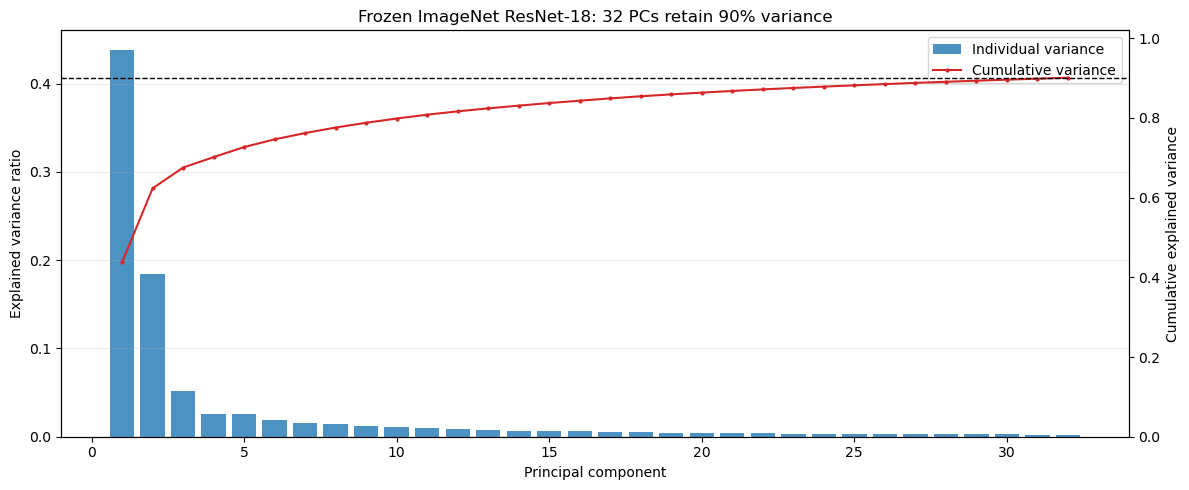

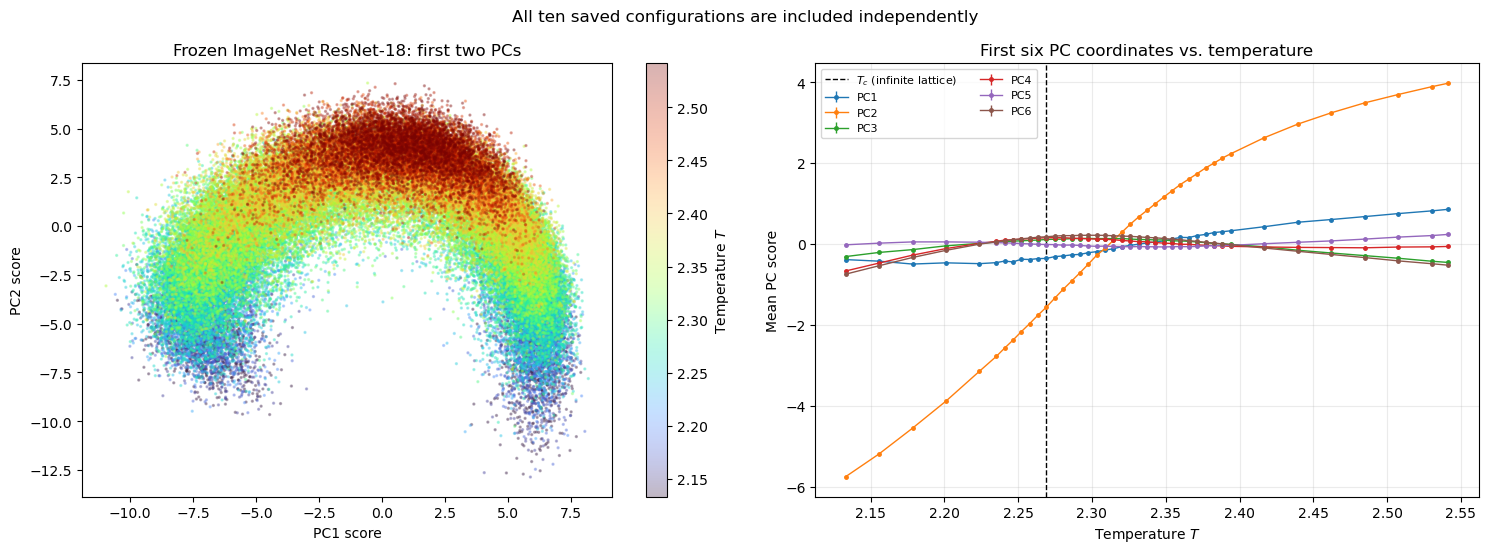

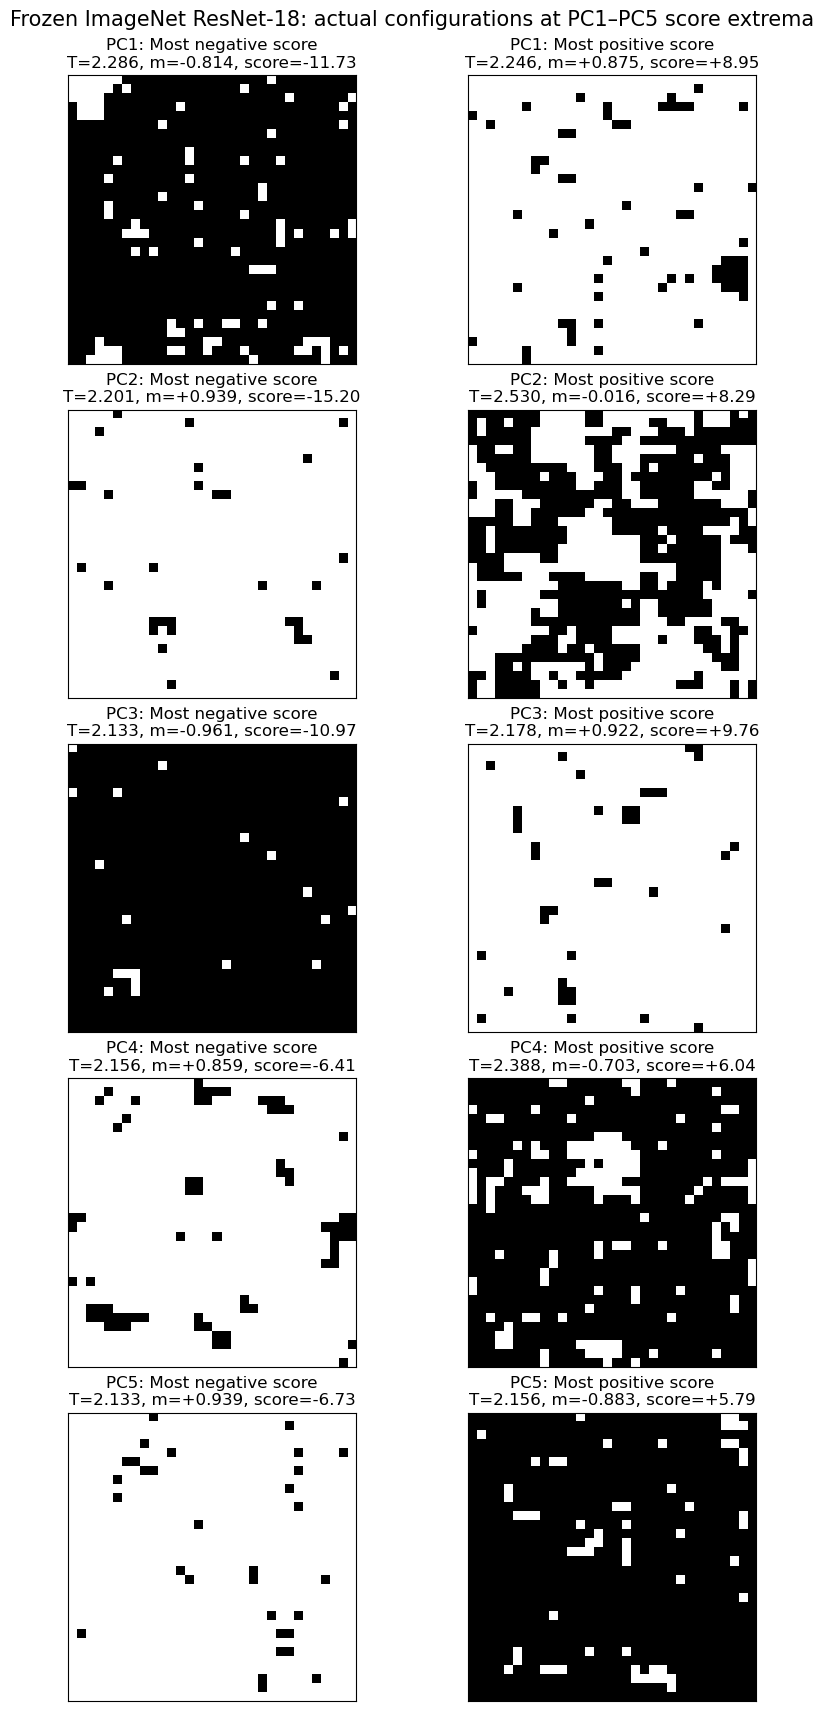

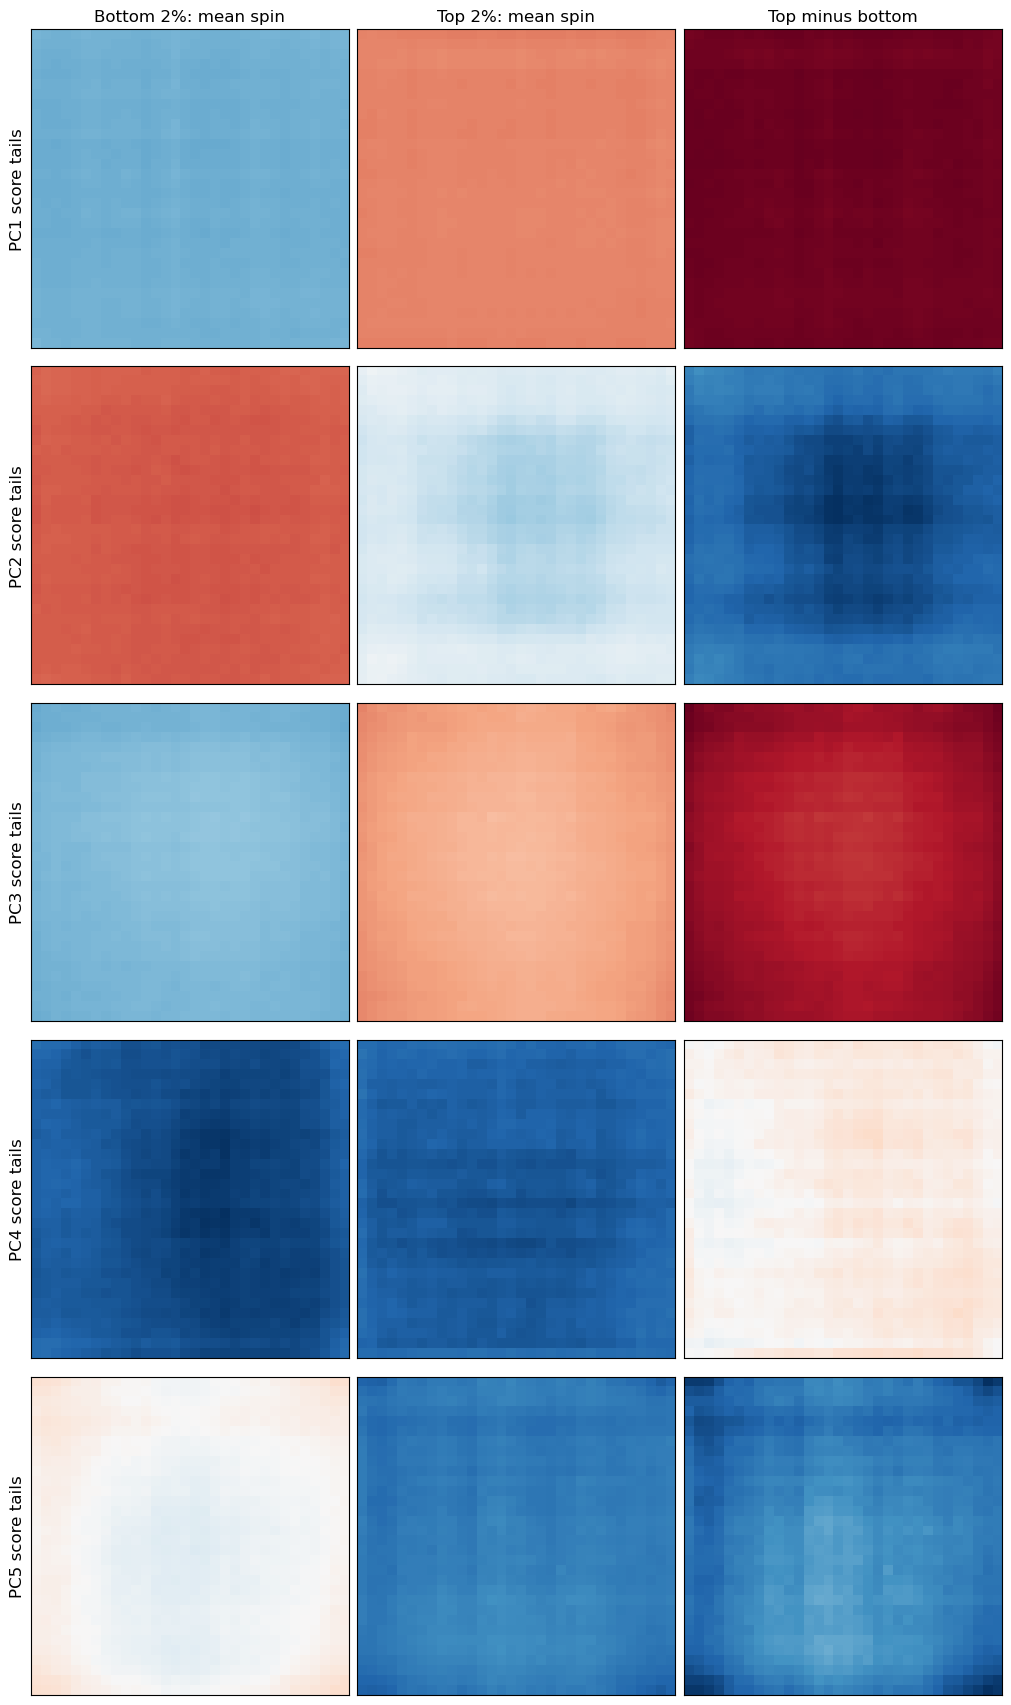

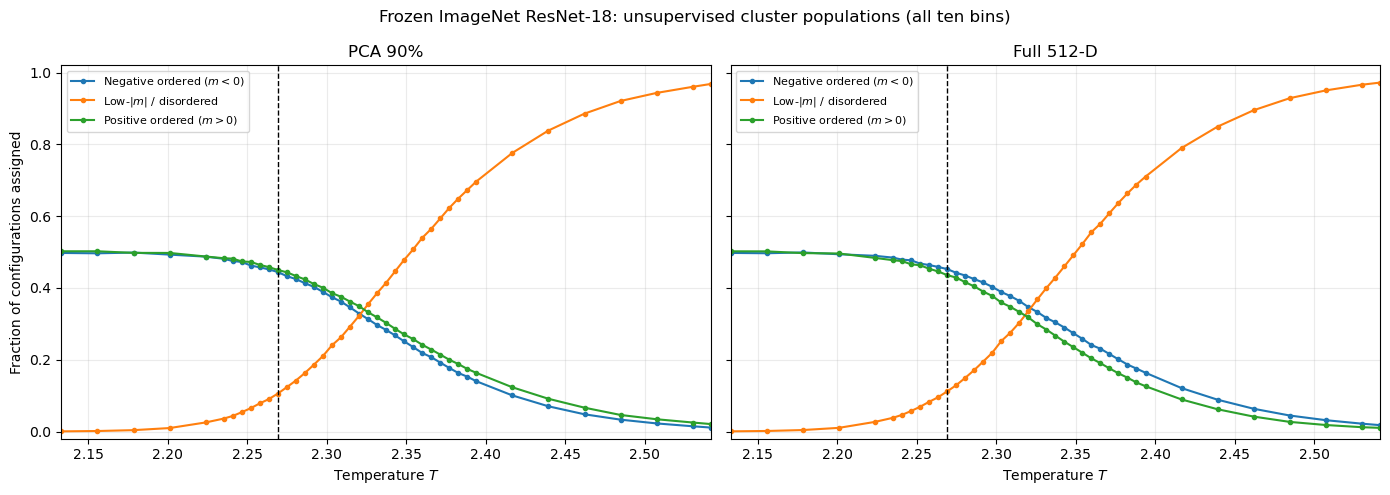

,method,cluster,physical_label,fraction,mean_m,mean_abs_m
0,PCA 90%,0,Negative ordered,0.302173,-0.687323,0.687329
1,PCA 90%,1,Low-|m| / disordered,0.382254,-0.015416,0.226350
2,PCA 90%,2,Positive ordered,0.315574,0.677717,0.677733
3,Full 512-D,0,Negative ordered,0.315469,-0.676610,0.676620
4,Full 512-D,1,Low-|m| / disordered,0.391049,0.024791,0.231668
5,Full 512-D,2,Positive ordered,0.293482,0.695243,0.695252


,method,silhouette,sample_size,PCA_vs_full_AMI
0,PCA 90%,0.287853,5125,0.872798
1,Full 512-D,0.249135,5125,0.872798


In [5]:
mean, eigenvalues, components = fit_covariance_pca(embeddings, OUTPUT_ROOT / "resnet18_all_bins_pca.npz")
evr, cumulative, n90 = variance_plot(eigenvalues, "Frozen ImageNet ResNet-18", "resnet18_all_bins_explained_variance.png")
scores6 = score_first_six(embeddings, mean, components, OUTPUT_ROOT / "resnet18_all_bins_pc1-6_scores.npy")
overview_plot(scores6, "Frozen ImageNet ResNet-18", "resnet18_all_bins_pca_overview.png")
tail_plots(scores6, "resnet18_all_bins", "Frozen ImageNet ResNet-18")
labels, cluster_summary, diagnostics = streamed_kmeans(embeddings, mean, components, n90, "resnet18_all_bins", "Frozen ImageNet ResNet-18")
with open(OUTPUT_ROOT / "resnet18_all_bins_summary.json", "w") as handle:
    json.dump({"observations": N_CONFIGURATIONS, "fit_observations": len(FIT_INDICES), "n90": n90, "first_six_evr": evr[:6].tolist()}, handle, indent=2)
display(cluster_summary, diagnostics)

## Mean-subtracted ResNet PC tails

For every configuration selected into a PC-score tail, subtract that configuration's own spatial mean spin, (s_i \rightarrow s_i-m), before averaging. This removes the uniform magnetization background while preserving location-dependent deviations. Each PC row uses one symmetric color scale shared by its bottom tail, top tail, and difference.

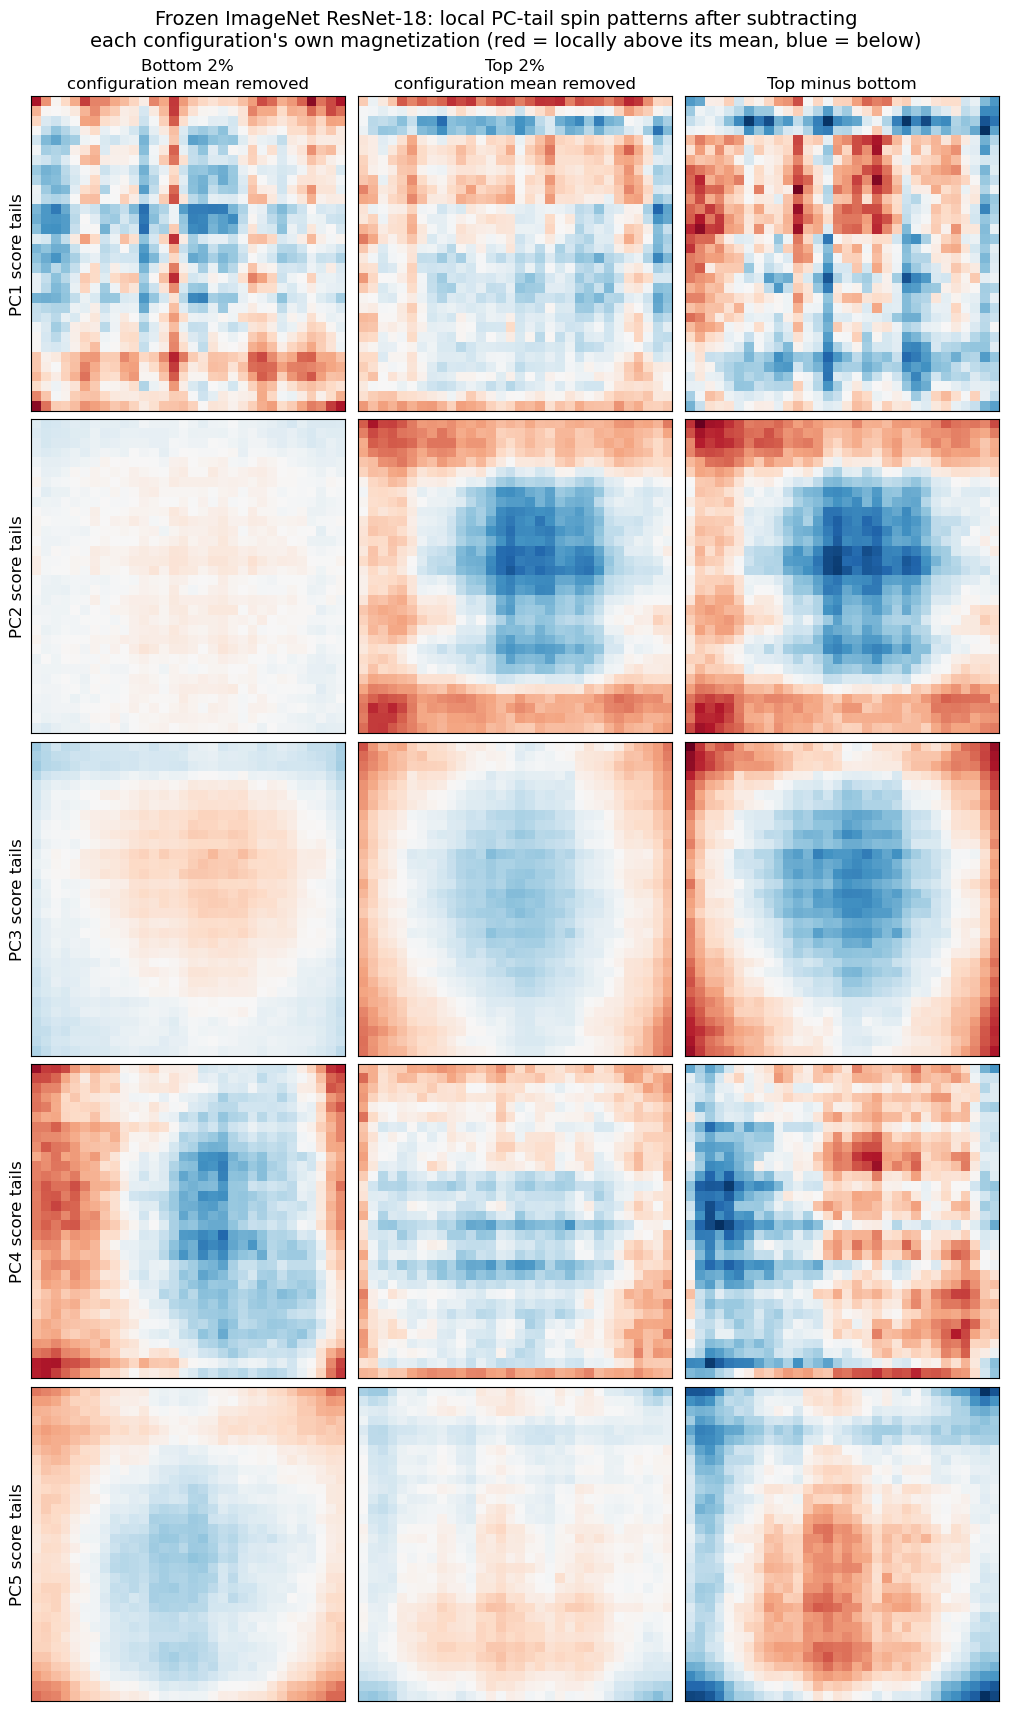

In [6]:
tail_count = max(1, int(0.02 * N_CONFIGURATIONS))
fig, axes = plt.subplots(5, 3, figsize=(10, 17), constrained_layout=True)

for pc in range(5):
    values = np.asarray(scores6[:, pc])
    low_indices = np.argpartition(values, tail_count)[:tail_count]
    high_indices = np.argpartition(values, len(values) - tail_count)[-tail_count:]

    def centered_tail_average(indices):
        selected = np.asarray(all_spins[indices], dtype=np.float32)
        selected -= selected.mean(axis=(1, 2), keepdims=True)
        return selected.mean(axis=0)

    low_centered = centered_tail_average(low_indices)
    high_centered = centered_tail_average(high_indices)
    difference = high_centered - low_centered
    maps = (low_centered, high_centered, difference)
    row_limit = max(float(np.max(np.abs(maps))), 1e-4)

    for column, image in enumerate(maps):
        axes[pc, column].imshow(
            image,
            cmap="RdBu_r",
            vmin=-row_limit,
            vmax=row_limit,
            interpolation="nearest",
        )
        axes[pc, column].set_xticks([])
        axes[pc, column].set_yticks([])
    axes[pc, 0].set_ylabel(f"PC{pc + 1} score tails", fontsize=12)

axes[0, 0].set_title("Bottom 2%\nconfiguration mean removed")
axes[0, 1].set_title("Top 2%\nconfiguration mean removed")
axes[0, 2].set_title("Top minus bottom")
fig.suptitle(
    "Frozen ImageNet ResNet-18: local PC-tail spin patterns after subtracting\n"
    "each configuration's own magnetization (red = locally above its mean, blue = below)",
    fontsize=14,
)
fig.savefig(
    OUTPUT_ROOT / "resnet18_all_bins_pc1-5_mean_subtracted_tail_patterns.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## Interpretation

This analysis uses all **4.1 million** seed–temperature–bin configurations independently on the 41-temperature grid spanning (0.94\le T/T_c\le1.12). No configuration averaging, spin-inversion preprocessing, temperature labels, or supervised classifier is used.

Frozen ResNet-18 needs **32 PCs** to retain 90% of its variance. The PCA-90 and full 512-D silhouette scores are **0.288** and **0.249**, and their cluster assignments agree strongly (AMI **0.873**). At the ordered endpoint, (T/T_c=0.94), the low-|m| cluster contains only **0.049%** (PCA-90) or **0.053%** (full embedding) of configurations. At (T/T_c=1.12), it contains **96.81%** and **97.19%**, respectively. The widened grid therefore captures both cluster plateaus that were absent from the earlier 2.20–2.40 sweep.

The PCA overview shows a continuous temperature-ordered arch in the first two ResNet PCs. PC2 is the dominant temperature-aligned mean coordinate, while the clearly titled raw and mean-subtracted tail figures show which uniform and spatial structures define PCs 1–5.